# EpiLink compatibility walkthrough

This notebook shows a practical EpiLink workflow:

- create a transmission profile and an `EpiLink` scorer
- inspect detailed per-scenario compatibility for one sampled pair
- use the cached `PairwiseCompatibilityModel` for fast array-valued scoring
- visualise compatibility surfaces for direct transmission, co-primary infection, and a recent-linkage subset

It assumes `epilink` is installed in the current environment, for example with `pip install -e .` from the project root.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from epilink import EpiLink, InfectiousnessToTransmission, NaturalHistoryParameters

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (8, 5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "figure.titlesize": 18,
    }
)

rng_seed = 2026


## Build an `EpiLink` model

We will use the infectiousness-to-transmission profile, configure a modest hidden-depth limit, and define a recent-linkage target subset consisting of direct transmission and co-primary infection.


In [2]:
parameters = NaturalHistoryParameters()
profile = InfectiousnessToTransmission(parameters=parameters, rng_seed=rng_seed)

epilink = EpiLink(
    transmission_profile=profile,
    maximum_depth=2,
    mc_samples=8000,
    target=["ad(0)", "ca(0,0)"],
    mutation_process="stochastic",
)

direct_model = epilink.pairwise_model("ad(0)")
coprimary_model = epilink.pairwise_model("ca(0,0)")
recent_linkage_model = epilink.pairwise_model(["ad(0)", "ca(0,0)"])

print("Configured target subset:", epilink.target_labels)
print("Available scenarios:", [scenario.label() for scenario in epilink.scenarios])


Configured target subset: ('ad(0)', 'ca(0,0)')
Available scenarios: ['ad(0)', 'ad(1)', 'ad(2)', 'ca(0,0)', 'ca(0,1)', 'ca(0,2)', 'ca(1,0)', 'ca(1,1)', 'ca(2,0)']


## Transmission-profile intuition

Before scoring pairs, it is useful to look at the underlying transmission-time density. This controls the temporal part of the compatibility calculation.


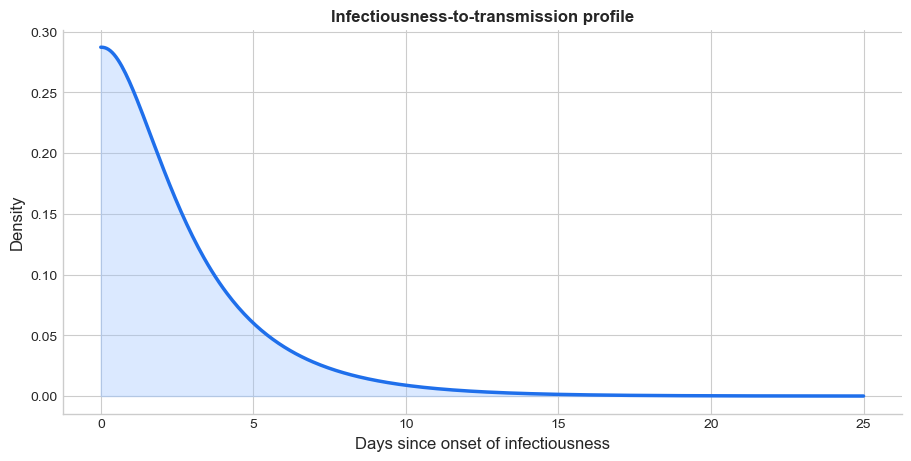

In [3]:
time_axis = np.linspace(0, 25, 400)
profile_density = profile.pdf(time_axis)

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
ax.plot(time_axis, profile_density, color="#1f6feb", linewidth=2.5)
ax.fill_between(time_axis, profile_density, color="#99c2ff", alpha=0.35)
ax.set(
    title="Infectiousness-to-transmission profile",
    xlabel="Days since onset of infectiousness",
    ylabel="Density",
)
plt.show()


## Inspect a single sampled pair

`score_pair()` is the detailed scalar interface: it returns compatibility components for every scenario as well as the score for the configured target subset.


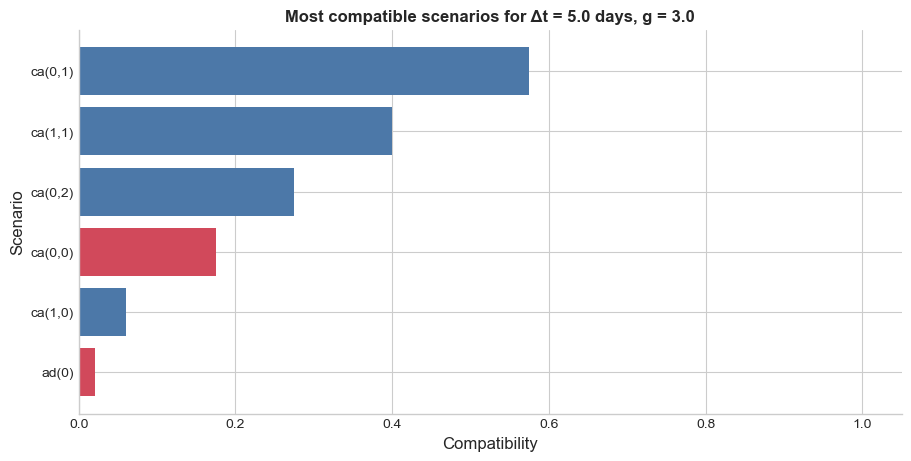

Target subset score: 0.19697156250000014


In [4]:
sample_time_difference = 5.0
genetic_distance = 3.0

pair_result = epilink.score_pair(
    sample_time_difference=sample_time_difference,
    genetic_distance=genetic_distance,
)

ranked = sorted(
    pair_result["scenario_scores"].items(),
    key=lambda item: item[1]["compatibility"],
    reverse=True,
)
top_labels = [label for label, _ in ranked[:6]]
top_scores = [values["compatibility"] for _, values in ranked[:6]]
target_labels = set(pair_result["target_labels"])

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
bar_colors = [
    "#d1495b" if label in target_labels else "#4c78a8"
    for label in top_labels[::-1]
]
ax.barh(top_labels[::-1], top_scores[::-1], color=bar_colors, edgecolor="none")
ax.set(
    title=f"Most compatible scenarios for Δt = {sample_time_difference:.1f} days, g = {genetic_distance:.1f}",
    xlabel="Compatibility",
    ylabel="Scenario",
)
ax.set_xlim(0, max(1.05, max(top_scores) * 1.05))
plt.show()

print("Target subset score:", pair_result["target_compatibility"])


## Compatibility surfaces

The cached `PairwiseCompatibilityModel` accepts arraylike inputs, so we can evaluate a full grid of temporal and genetic observations in one call. Because the subset score is a sum over scenarios, the combined surface can exceed 1.


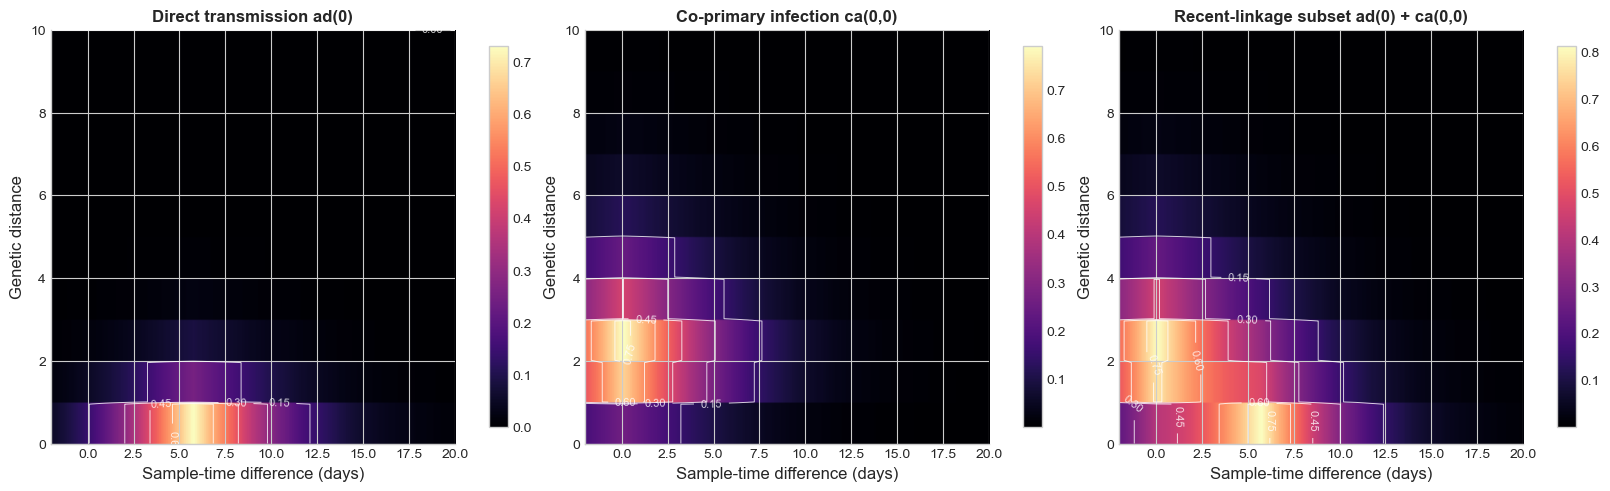

In [5]:
time_grid = np.linspace(-2, 20, 180)
genetic_grid = np.linspace(0, 10, 180)
T, G = np.meshgrid(time_grid, genetic_grid)

surface_direct = direct_model(T, G)
surface_coprimary = coprimary_model(T, G)
surface_recent = recent_linkage_model(T, G)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
surfaces = [
    ("Direct transmission ad(0)", surface_direct),
    ("Co-primary infection ca(0,0)", surface_coprimary),
    ("Recent-linkage subset ad(0) + ca(0,0)", surface_recent),
]

for ax, (title, surface) in zip(axes, surfaces):
    image = ax.imshow(
        surface,
        origin="lower",
        extent=[time_grid.min(), time_grid.max(), genetic_grid.min(), genetic_grid.max()],
        aspect="auto",
        cmap="magma",
    )
    contours = ax.contour(
        time_grid,
        genetic_grid,
        surface,
        levels=5,
        colors="white",
        linewidths=0.7,
        alpha=0.8,
    )
    ax.clabel(contours, inline=True, fontsize=8, fmt="%.2f")
    ax.set(title=title, xlabel="Sample-time difference (days)", ylabel="Genetic distance")
    fig.colorbar(image, ax=ax, shrink=0.92)

plt.show()


## Behaviour along fixed slices

Line slices make it easier to see how compatibility changes when one observation is held fixed and the other varies.


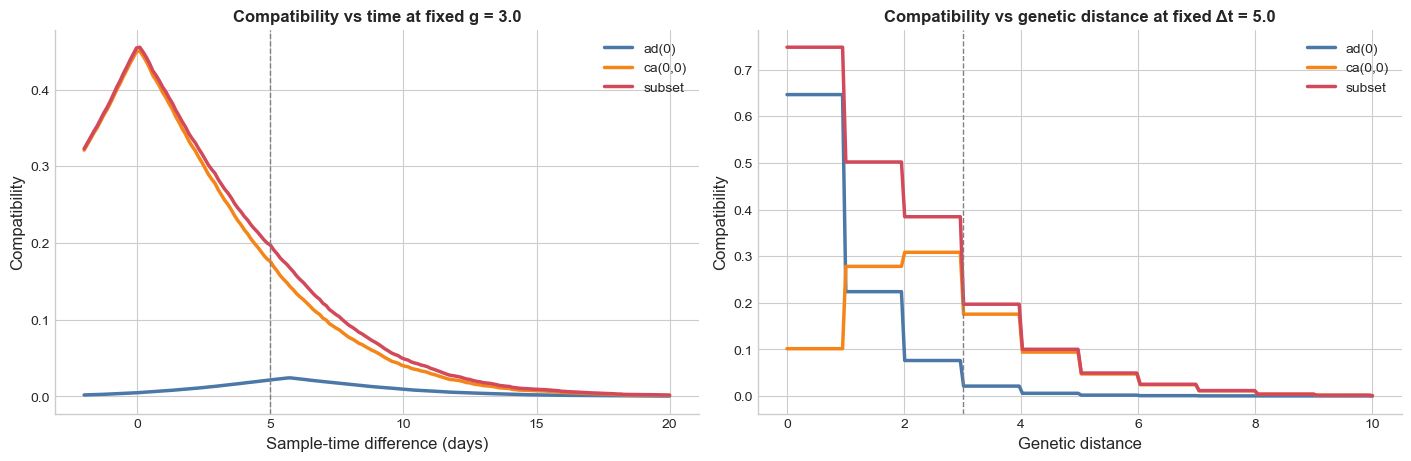

In [6]:
fixed_genetic = 3.0
fixed_time = 5.0

time_slice_direct = direct_model(time_grid, np.full_like(time_grid, fixed_genetic))
time_slice_coprimary = coprimary_model(time_grid, np.full_like(time_grid, fixed_genetic))
time_slice_recent = recent_linkage_model(time_grid, np.full_like(time_grid, fixed_genetic))

genetic_slice_direct = direct_model(np.full_like(genetic_grid, fixed_time), genetic_grid)
genetic_slice_coprimary = coprimary_model(np.full_like(genetic_grid, fixed_time), genetic_grid)
genetic_slice_recent = recent_linkage_model(np.full_like(genetic_grid, fixed_time), genetic_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(time_grid, time_slice_direct, label="ad(0)", linewidth=2.5, color="#4c78a8")
axes[0].plot(time_grid, time_slice_coprimary, label="ca(0,0)", linewidth=2.5, color="#f58518")
axes[0].plot(time_grid, time_slice_recent, label="subset", linewidth=2.5, color="#d1495b")
axes[0].axvline(fixed_time, color="0.5", linestyle="--", linewidth=1)
axes[0].set(
    title=f"Compatibility vs time at fixed g = {fixed_genetic}",
    xlabel="Sample-time difference (days)",
    ylabel="Compatibility",
)
axes[0].legend(loc="upper right")

axes[1].plot(genetic_grid, genetic_slice_direct, label="ad(0)", linewidth=2.5, color="#4c78a8")
axes[1].plot(genetic_grid, genetic_slice_coprimary, label="ca(0,0)", linewidth=2.5, color="#f58518")
axes[1].plot(genetic_grid, genetic_slice_recent, label="subset", linewidth=2.5, color="#d1495b")
axes[1].axvline(fixed_genetic, color="0.5", linestyle="--", linewidth=1)
axes[1].set(
    title=f"Compatibility vs genetic distance at fixed Δt = {fixed_time}",
    xlabel="Genetic distance",
    ylabel="Compatibility",
)
axes[1].legend(loc="upper right")
plt.show()


## Next steps

A few easy extensions from here:

- change `maximum_depth` to include deeper latent scenarios
- switch to `mutation_process="stochastic"` to inspect noisier genetic surfaces
- replace the target subset with scenarios that match your study definition of plausible linkage
- score whole cohorts by calling `score_target()` or a cached `pairwise_model()` on broadcasted arrays
